In [1]:
from unc_handling import UG_prompter
from DataLoader import DataLoader
from segmentation import Segmentation
from segmentation_util import combine_prompt_sets
from evaluation import Evaluator, save_evaluation_results, evaluate_slice_by_slice, compute_contour_within_clinical_boundary
from uncertainty_util import remove_negative_prompts, remove_positive_prompts
from pathlib import Path
import numpy as np
import pandas as pd


root = r"C:\Users\20202310\Desktop\MSc scriptie\MSc_Graduation_Project\data\LUNDPROBE\ExtendedSamples\development"

methods_available = ["raycast", "local_normals"]
propagation_styles = ['default', 'full', 'prompt_based', 'central_start', 'central_partitions']
method = methods_available[1]
propagation_style = propagation_styles[3]

rootpath = Path(root)
subjects = sorted([p.name for p in rootpath.iterdir() if p.is_dir()])
print(subjects)

['newAcq_050f229dc2bdb64c', 'newAcq_0b4940fa31a1d650', 'newAcq_0cc559a8bd82a14a', 'newAcq_1b911d6cb2348f30', 'newAcq_1e0f8b9b01ce5f0b', 'newAcq_250d6075dd465a1a', 'newAcq_433a8d44fddd5b7f', 'newAcq_47ceabdbca398517', 'newAcq_486b7494ee9d71e7', 'newAcq_4a136e8fe320bd13']


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


def evaluate_saved_logit_fusion(
    root,
    subjects,
    weights=(0.5, 0.5),
    logits_folder="saved_logits",
    output_folder="fusion_evaluation",
    threshold=0.0,
    surface_dice_tol=1.0,
):
    """
    Create segmentations from weighted saved logit maps and evaluate them
    both per volume and per slice.

    Assumes each .npz file contains:
        - "Dense_and_nietjes"
        - "Uncertainty_bboxes"
    """

    weight_dense, weight_bbox = weights

    logits_folder = Path(logits_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    volume_results = []
    slice_results = []

    for subject_nr in range(len(subjects)):
        # Load image data, ground truth, spacing, uncertainty, etc.
        data = DataLoader(
            parentfolder=root,
            subject_nr=subject_nr,
            volume_of_interest="CTVT",
            verbose=True,
        )

        data.load_recontours()
        data.load_consensus(indices = [0, 2, 3])

        subject_name = data.subject_name

        logits_path = (
            logits_folder /
            f"{subject_name}_logits.npz"
        )

        # The context manager closes the .npz file after loading.
        with np.load(logits_path) as saved_logits:
            print(f"Available arrays: {saved_logits.files}")

            dense_logits = saved_logits[
                "Dense_and_nietjes"
            ].astype(np.float32)

            bbox_logits = saved_logits[
                "Uncertainty_bboxes"
            ].astype(np.float32)

        # Weighted logit fusion
        fused_logits = (
            weight_dense * dense_logits
            + weight_bbox * bbox_logits
        )

        # Convert fused logits to a binary segmentation
        fused_seg = fused_logits > threshold
        
        #===================================================
        #===============VOLUME EVALUATOR====================
        #===================================================
        volume_evaluator = Evaluator(
            pred=fused_seg,
            gt=data.consensus_recontour,
            spacing=data.img_spacing,
            subject_name=subject_name,
        )
        #===================================================

        volume_metrics = volume_evaluator.compute_all(
            surface_dice_tol=surface_dice_tol
        )

        volume_metrics["StapleWeight"] = weight_dense
        volume_metrics["BBoxWeight"] = weight_bbox
        volume_metrics["LogitThreshold"] = threshold

        volume_results.append(volume_metrics)

        #===================================================
        #===============SLICE EVALUATOR=====================
        #===================================================
        subject_slice_results = evaluate_slice_by_slice(
            pred=fused_seg,
            gt=data.consensus_recontour,
            uncertainty=data.unc_map,
            spacing=data.img_spacing,
            subject_name=subject_name,
            surface_dice_tol=surface_dice_tol,
        )
        #===================================================

        subject_slice_results["StapleWeight"] = weight_dense
        subject_slice_results["BBoxWeight"] = weight_bbox
        subject_slice_results["LogitThreshold"] = threshold

        slice_results.append(subject_slice_results)
        print(f"Evaluated and saved fusion for {subject_name}")

    # --------------------------------------------------------
    # Combine and save results
    # --------------------------------------------------------
    volume_df = pd.DataFrame(volume_results)

    if slice_results:
        slice_df = pd.concat(slice_results, ignore_index=True)
    else:
        slice_df = pd.DataFrame()

    weight_name = f"Staple_{weight_dense}_bbox_{weight_bbox}"

    volume_csv = output_folder / "Volume results" / f"volume_results_{weight_name}.csv"
    slice_csv = output_folder / "Slice results" / f"slice_results_{weight_name}.csv"

    volume_csv.parent.mkdir(parents=True, exist_ok=True)
    slice_csv.parent.mkdir(parents=True, exist_ok=True)

    volume_df.to_csv(volume_csv, index=False)
    slice_df.to_csv(slice_csv, index=False)

    print(f"\nSaved volume evaluation to:\n{volume_csv}")
    print(f"\nSaved slice-wise evaluation to:\n{slice_csv}")

    return volume_df, slice_df

In [3]:
weighting_list = [
    (0.0, 1.0),
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
    (1.0, 0.0),
]

for weights in weighting_list:
    evaluate_saved_logit_fusion(
        root=root,
        subjects=subjects,
        weights=weights,
        logits_folder="saved_logits_new",
        output_folder="fusion_evaluation",
        surface_dice_tol=1.0,
    )

Loaded subject newAcq_050f229dc2bdb64c with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Available arrays: ['Dense_and_nietjes', 'Uncertainty_bboxes']
Evaluating slices 27 to 44...
Number of evaluated slices: 18
Evaluated and saved fusion for newAcq_050f229dc2bdb64c
Loaded subject newAcq_0b4940fa31a1d650 with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Available arrays: ['Dense_and_nietjes', 'Uncertainty_bboxes']
Evaluating slices 23 to 50...
Number of evaluated slices: 28
Evaluated and saved fusion for newAcq_0b4940fa31a1d650
Loaded subject newAcq_0cc559a8bd82a14a with volume of interest 'CTVT'
Image shap

In [4]:
from pathlib import Path
import pandas as pd


def evaluate_existing_masks(
    root,
    subjects,
    output_folder="existing_mask_evaluation",
    surface_dice_tol=1.0,
):
    """
    Evaluate nnUNet and each observer against the consensus.

    Saves separate volume-wise and slice-wise CSV files for:
        - nnUnet
        - obsB
        - obsC
        - obsD
        - obsE
    """

    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    result_names = ["nnUnet", "obsB", "obsC", "obsD", "obsE"]

    volume_results = {
        name: []
        for name in result_names
    }

    slice_results = {
        name: []
        for name in result_names
    }

    for subject_nr in range(len(subjects)):

        data = DataLoader(
            parentfolder=root,
            subject_nr=subject_nr,
            volume_of_interest="CTVT",
            verbose=True,
        )

        data.load_recontours()
        data.load_consensus(indices = [0,2,3])

        subject_name = data.subject_name

        # ====================================================
        # Masks to evaluate against the consensus
        # ====================================================

        masks_to_evaluate = {
            "nnUnet": data.mask,
            "obsB": data.observer_recontours[0],
            "obsC": data.observer_recontours[1],
            "obsD": data.observer_recontours[2],
            "obsE": data.observer_recontours[3],
        }

        for result_name, pred in masks_to_evaluate.items():

            #===================================================
            #===============VOLUME EVALUATOR====================
            #===================================================
            volume_evaluator = Evaluator(
                pred=pred,
                gt=data.consensus_recontour,
                spacing=data.img_spacing,
                subject_name=subject_name,
            )
            #===================================================

            volume_metrics = volume_evaluator.compute_all(
                surface_dice_tol=surface_dice_tol
            )

            volume_results[result_name].append(volume_metrics)

            #===================================================
            #===============SLICE EVALUATOR=====================
            #===================================================
            subject_slice_results = evaluate_slice_by_slice(
                pred=pred,
                gt=data.consensus_recontour,
                uncertainty=data.unc_map,
                spacing=data.img_spacing,
                subject_name=subject_name,
                surface_dice_tol=surface_dice_tol,
            )
            #===================================================


            slice_results[result_name].append(
                subject_slice_results
            )

        print(f"Evaluated {subject_name}")

    # ========================================================
    # Combine and save each evaluation separately
    # ========================================================

    saved_volume_dfs = {}
    saved_slice_dfs = {}

    for result_name in result_names:

        volume_df = pd.DataFrame(
            volume_results[result_name]
        )

        if slice_results[result_name]:
            slice_df = pd.concat(
                slice_results[result_name],
                ignore_index=True,
            )
        else:
            slice_df = pd.DataFrame()

        volume_csv = output_folder / "Volume results" / f"{result_name}_volume.csv"
        slice_csv = output_folder / "Slice results" / f"{result_name}_slice.csv"

        # Ensure the directories exist
        volume_csv.parent.mkdir(parents=True, exist_ok=True)
        slice_csv.parent.mkdir(parents=True, exist_ok=True)

        volume_df.to_csv(volume_csv, index=False)
        slice_df.to_csv(slice_csv, index=False)

        saved_volume_dfs[result_name] = volume_df
        saved_slice_dfs[result_name] = slice_df

        print(f"Saved {volume_csv}")
        print(f"Saved {slice_csv}")

    return saved_volume_dfs, saved_slice_dfs

In [5]:
evaluate_existing_masks(
    root=root,
    subjects=subjects,
    output_folder="fusion_evaluation",
    surface_dice_tol=1.0,
)

Loaded subject newAcq_050f229dc2bdb64c with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Evaluating slices 27 to 44...
Number of evaluated slices: 18
Evaluating slices 28 to 44...
Number of evaluated slices: 17
Evaluating slices 27 to 44...
Number of evaluated slices: 18
Evaluating slices 27 to 44...
Number of evaluated slices: 18
Evaluating slices 27 to 44...
Number of evaluated slices: 18
Evaluated newAcq_050f229dc2bdb64c
Loaded subject newAcq_0b4940fa31a1d650 with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Evaluating slices 23 to 50...
Number of evaluated slices: 28
Evaluating slices 23 to 51...
Number

({'nnUnet':               subject name      HD_mm   HD95_mm    MSD_mm   ASSD_mm      Dice  \
  0  newAcq_050f229dc2bdb64c   2.586416  1.325967  0.194261  0.195960  0.978829   
  1  newAcq_0b4940fa31a1d650  13.835670  5.250526  0.834348  0.793096  0.921978   
  2  newAcq_0cc559a8bd82a14a   2.670036  0.662983  0.146313  0.139223  0.985024   
  3  newAcq_1b911d6cb2348f30   2.500000  0.468800  0.097149  0.095200  0.982164   
  4  newAcq_1e0f8b9b01ce5f0b   3.017790  0.937600  0.179073  0.187033  0.975341   
  5  newAcq_250d6075dd465a1a   2.670036  0.468800  0.134637  0.141989  0.985449   
  6  newAcq_433a8d44fddd5b7f   2.829874  0.662983  0.151667  0.144540  0.977583   
  7  newAcq_47ceabdbca398517   5.194031  2.500000  0.260787  0.315383  0.969596   
  8  newAcq_486b7494ee9d71e7   2.500000  0.498000  0.137467  0.133554  0.979254   
  9  newAcq_4a136e8fe320bd13   5.000000  1.875200  0.263497  0.261331  0.973318   
  
     SurfaceDice@1.0mm  SurfaceDice@2.0mm  CentroidDistance_mm  \
  0     

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd


def evaluate_saved_logit_clinical_boundary(
    root,
    subjects,
    weighting_lists,
    logits_folder="saved_logits",
    output_folder="clinical_boundary_evaluation",
    threshold=0.0,
):
    """
    Evaluate the percentage of the predicted contour/surface that lies
    within the observer-defined clinical contour range.

    Computes:
        - one volume-wise score per subject × weighting
        - one slice-wise score per slice × subject × weighting
    """

    logits_folder = Path(logits_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    volume_results = []
    slice_results = []

    for subject_nr in range(len(subjects)):

        data = DataLoader(
            parentfolder=root,
            subject_nr=subject_nr,
            volume_of_interest="CTVT",
            verbose=True,
        )

        data.load_recontours()

        subject_name = data.subject_name

        summed_recontours = data.load_summed_recontours(indices=[0, 1, 2, 3])

        logits_path = (
            logits_folder /
            f"{subject_name}_logits.npz"
        )

        with np.load(logits_path) as saved_logits:

            dense_logits = saved_logits[
                "Dense_and_nietjes"
            ].astype(np.float32)

            bbox_logits = saved_logits[
                "Uncertainty_bboxes"
            ].astype(np.float32)

        #Loop through weightings
        for weights in weighting_lists:

            weight_dense, weight_bbox = weights

            fused_logits = (
                weight_dense * dense_logits
                + weight_bbox * bbox_logits
            )

            fused_seg = fused_logits > threshold

            # =================================================
            # VOLUME-WISE METRIC
            # =================================================
            volume_score = compute_contour_within_clinical_boundary(
                fused_seg,
                summed_recontours
            )

            volume_results.append({
                "subject": subject_name,
                "ContourWithinClinicalBoundary": volume_score,
                "StapleWeight": weight_dense,
                "BBoxWeight": weight_bbox,
                "LogitThreshold": threshold,
            })

            # =================================================
            # SLICE-WISE METRIC
            # =================================================

            for z in range(fused_seg.shape[0]):

                pred_slice = fused_seg[z]

                if not pred_slice.any():
                    continue

                slice_score = compute_contour_within_clinical_boundary(
                    pred_slice,
                    summed_recontours[z]
                )

                slice_results.append({
                    "subject": subject_name,
                    "slice_idx": z,
                    "ContourWithinClinicalBoundary": slice_score,
                    "StapleWeight": weight_dense,
                    "BBoxWeight": weight_bbox,
                    "LogitThreshold": threshold,
                })

            print(
                f"Evaluated {subject_name} | "
                f"Staple={weight_dense:.1f}, "
                f"BBox={weight_bbox:.1f}"
            )

    #Create dataframes
    volume_df = pd.DataFrame(volume_results)
    slice_df = pd.DataFrame(slice_results)

    volume_csv = output_folder / "clinical_boundary_volume_results.csv"
    slice_csv = output_folder / "clinical_boundary_slice_results.csv"

    volume_df.to_csv(volume_csv, index=False)
    slice_df.to_csv(slice_csv, index=False)

    print(f"\nSaved volume results to:\n{volume_csv}")
    print(f"\nSaved slice results to:\n{slice_csv}")

    return volume_df, slice_df

In [3]:
weighting_lists = [
    (0.0, 1.0),
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
    (1.0, 0.0),
]

volume_clinical_df, slice_clinical_df = (
    evaluate_saved_logit_clinical_boundary(
        root=root,
        subjects=subjects,
        weighting_lists=weighting_lists,
        logits_folder="saved_logits_new",
        output_folder="fusion_evaluation",
        threshold=0.0,
    )
)

Loaded subject newAcq_050f229dc2bdb64c with volume of interest 'CTVT'
Image shape: (88, 1024, 1024), Mask shape: (88, 1024, 1024), Uncertainty map shape: (88, 1024, 1024), Ground truth shape: (88, 1024, 1024)
Image spacing (z, y, x): (2.5, 0.46880000829696655, 0.46880000829696655)
Evaluated newAcq_050f229dc2bdb64c | Staple=0.0, BBox=1.0
Evaluated newAcq_050f229dc2bdb64c | Staple=0.1, BBox=0.9
Evaluated newAcq_050f229dc2bdb64c | Staple=0.2, BBox=0.8
Evaluated newAcq_050f229dc2bdb64c | Staple=0.3, BBox=0.7
Evaluated newAcq_050f229dc2bdb64c | Staple=0.4, BBox=0.6
Evaluated newAcq_050f229dc2bdb64c | Staple=0.5, BBox=0.5
Evaluated newAcq_050f229dc2bdb64c | Staple=0.6, BBox=0.4
Evaluated newAcq_050f229dc2bdb64c | Staple=0.7, BBox=0.3
Evaluated newAcq_050f229dc2bdb64c | Staple=0.8, BBox=0.2
Evaluated newAcq_050f229dc2bdb64c | Staple=0.9, BBox=0.1
Evaluated newAcq_050f229dc2bdb64c | Staple=1.0, BBox=0.0
Loaded subject newAcq_0b4940fa31a1d650 with volume of interest 'CTVT'
Image shape: (88, 102

In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def plot_all_weightings_edits_by_uncertainty(
    root,
    subjects,
    weighting_lists,
    logits_folder="saved_logits",
    threshold=0.0,
    normalize=False,
    crop_margin=30,
    figsize=(14, 7),
):

    logits_folder = Path(logits_folder)

    uncertainty_edges = np.array([
        0.0, 0.1, 0.2, 0.3, 0.4, 0.5
    ])

    bracket_labels = [
        "0.0–0.1",
        "0.1–0.2",
        "0.2–0.3",
        "0.3–0.4",
        "0.4–0.5",
    ]

    observer_names = [
        "Observer B",
        "Observer C",
        "Observer D",
        "Observer E",
    ]

    # Initialize result arrays
    aggregated_counts = {}

    for weight_dense, weight_bbox in weighting_lists:
        label = f"{weight_dense:.1f} / {weight_bbox:.1f}"
        aggregated_counts[label] = np.zeros(
            len(bracket_labels),
            dtype=int
        )

    for name in observer_names:
        aggregated_counts[name] = np.zeros(
            len(bracket_labels),
            dtype=int
        )

    # ========================================================
    # LOOP THROUGH SUBJECTS
    # ========================================================

    for subject_nr in range(len(subjects)):

        # Load subject only ONCE
        data = DataLoader(
            parentfolder=root,
            subject_nr=subject_nr,
            volume_of_interest="CTVT",
            verbose=False,
        )

        data.load_recontours()

        subject_name = data.subject_name

        datamask = data.mask.astype(bool)
        uncertainty_map = np.asarray(data.unc_map, dtype=float)
        observers = np.stack(data.observer_recontours, axis=0).astype(bool)

        # ----------------------------------------------------
        # Load logits only ONCE
        # ----------------------------------------------------

        logits_path = (
            logits_folder /
            f"{subject_name}_logits.npz"
        )

        if not logits_path.exists():
            print(f"Skipping {subject_name}: logits not found.")
            continue

        with np.load(logits_path) as saved_logits:

            dense_logits = saved_logits[
                "Dense_and_nietjes"
            ].astype(np.float32)

            bbox_logits = saved_logits[
                "Uncertainty_bboxes"
            ].astype(np.float32)

        # ----------------------------------------------------
        # Find relevant crop
        # ----------------------------------------------------

        foreground = (
            datamask
            | np.any(observers, axis=0)
            | (dense_logits > threshold)
            | (bbox_logits > threshold)
        )

        z, y, x = np.where(foreground)

        z0 = max(z.min() - crop_margin, 0)
        z1 = min(z.max() + crop_margin + 1, foreground.shape[0])

        y0 = max(y.min() - crop_margin, 0)
        y1 = min(y.max() + crop_margin + 1, foreground.shape[1])

        x0 = max(x.min() - crop_margin, 0)
        x1 = min(x.max() + crop_margin + 1, foreground.shape[2])

        # ----------------------------------------------------
        # Crop EVERYTHING identically
        # ----------------------------------------------------

        crop = np.s_[z0:z1, y0:y1, x0:x1]

        datamask = datamask[crop]
        uncertainty_map = uncertainty_map[crop]

        dense_logits = dense_logits[crop]
        bbox_logits = bbox_logits[crop]

        observers = observers[
            :,
            z0:z1,
            y0:y1,
            x0:x1
        ]

        print(
            f"{subject_name}: cropped to "
            f"{datamask.shape}"
        )

        # ----------------------------------------------------
        # Precompute uncertainty brackets ONCE
        # ----------------------------------------------------

        valid_uncertainty = np.isfinite(
            uncertainty_map
        )

        bracket_masks = []

        for i in range(len(uncertainty_edges) - 1):

            lower = uncertainty_edges[i]
            upper = uncertainty_edges[i + 1]

            if i == len(uncertainty_edges) - 2:

                bracket_mask = (
                    (uncertainty_map >= lower)
                    & (uncertainty_map <= upper)
                    & valid_uncertainty
                )

            else:

                bracket_mask = (
                    (uncertainty_map >= lower)
                    & (uncertainty_map < upper)
                    & valid_uncertainty
                )

            bracket_masks.append(bracket_mask)

        # ====================================================
        # OBSERVER EDITS
        # ====================================================

        for observer_idx, observer_name in enumerate(observer_names):

            edited_voxels = (
                observers[observer_idx] != datamask
            )

            for i, bracket_mask in enumerate(bracket_masks):

                aggregated_counts[observer_name][i] += (
                    np.count_nonzero(
                        edited_voxels & bracket_mask
                    )
                )

        # ====================================================
        # ALL LOGIT WEIGHTINGS
        # ====================================================

        for weight_dense, weight_bbox in weighting_lists:

            label = (
                f"{weight_dense:.1f} / "
                f"{weight_bbox:.1f}"
            )

            fused_seg = (
                weight_dense * dense_logits
                + weight_bbox * bbox_logits
            ) > threshold

            edited_voxels = (
                fused_seg != datamask
            )

            for i, bracket_mask in enumerate(bracket_masks):

                aggregated_counts[label][i] += (
                    np.count_nonzero(
                        edited_voxels & bracket_mask
                    )
                )

        print(f"Finished {subject_name}")

    # ========================================================
    # PREPARE PLOT
    # ========================================================

    result_names = list(
        aggregated_counts.keys()
    )

    plot_values = np.vstack([
        aggregated_counts[name]
        for name in result_names
    ]).astype(float)

    if normalize:

        totals = plot_values.sum(
            axis=1,
            keepdims=True
        )

        plot_values = np.divide(
            plot_values * 100,
            totals,
            out=np.zeros_like(plot_values),
            where=totals != 0,
        )

    # ========================================================
    # PLOT
    # ========================================================

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(bracket_labels))

    weight_labels = [
        f"{weight_dense:.1f} / {weight_bbox:.1f}"
        for weight_dense, weight_bbox in weighting_lists
    ]

    # Red shades for MedSAM weightings
    red_colors = plt.cm.Reds(
        np.linspace(0.3, 0.95, len(weight_labels))
    )

    # Blue shades for observers
    blue_colors = plt.cm.Blues(
        np.linspace(0.4, 0.9, len(observer_names))
    )

    colors = list(red_colors) + list(blue_colors)

    n_results = len(result_names)

    total_group_width = 0.9
    bar_width = total_group_width / n_results

    for i, name in enumerate(result_names):

        offset = (
            i - (n_results - 1) / 2
        ) * bar_width

        ax.bar(
            x + offset,
            plot_values[i],
            width=bar_width,
            label=name,
            color=colors[i],
        )

    ax.set_xticks(x)
    ax.set_xticklabels(bracket_labels)

    ax.set_xlabel("Voxel-wise uncertainty bracket")

    if normalize:
        ax.set_ylabel("Percentage of edits (%)")
        ax.set_title(
            "Distribution of segmentation edits across uncertainty brackets"
        )
    else:
        ax.set_ylabel("Number of edited voxels")
        ax.set_title(
            "Segmentation edits across uncertainty brackets"
        )

    ax.legend(
        title="Staple / BBox weighting",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()
    plt.show()

    return aggregated_counts, fig, ax

newAcq_050f229dc2bdb64c: cropped to (75, 153, 183)
Finished newAcq_050f229dc2bdb64c
newAcq_0b4940fa31a1d650: cropped to (82, 177, 179)
Finished newAcq_0b4940fa31a1d650
newAcq_0cc559a8bd82a14a: cropped to (84, 172, 196)
Finished newAcq_0cc559a8bd82a14a
newAcq_1b911d6cb2348f30: cropped to (76, 159, 170)
Finished newAcq_1b911d6cb2348f30
newAcq_1e0f8b9b01ce5f0b: cropped to (81, 154, 172)
Finished newAcq_1e0f8b9b01ce5f0b
newAcq_250d6075dd465a1a: cropped to (83, 178, 197)
Finished newAcq_250d6075dd465a1a
newAcq_433a8d44fddd5b7f: cropped to (77, 156, 169)
Finished newAcq_433a8d44fddd5b7f
newAcq_47ceabdbca398517: cropped to (79, 144, 147)
Finished newAcq_47ceabdbca398517
newAcq_486b7494ee9d71e7: cropped to (77, 141, 156)
Finished newAcq_486b7494ee9d71e7
newAcq_4a136e8fe320bd13: cropped to (79, 179, 188)
Finished newAcq_4a136e8fe320bd13


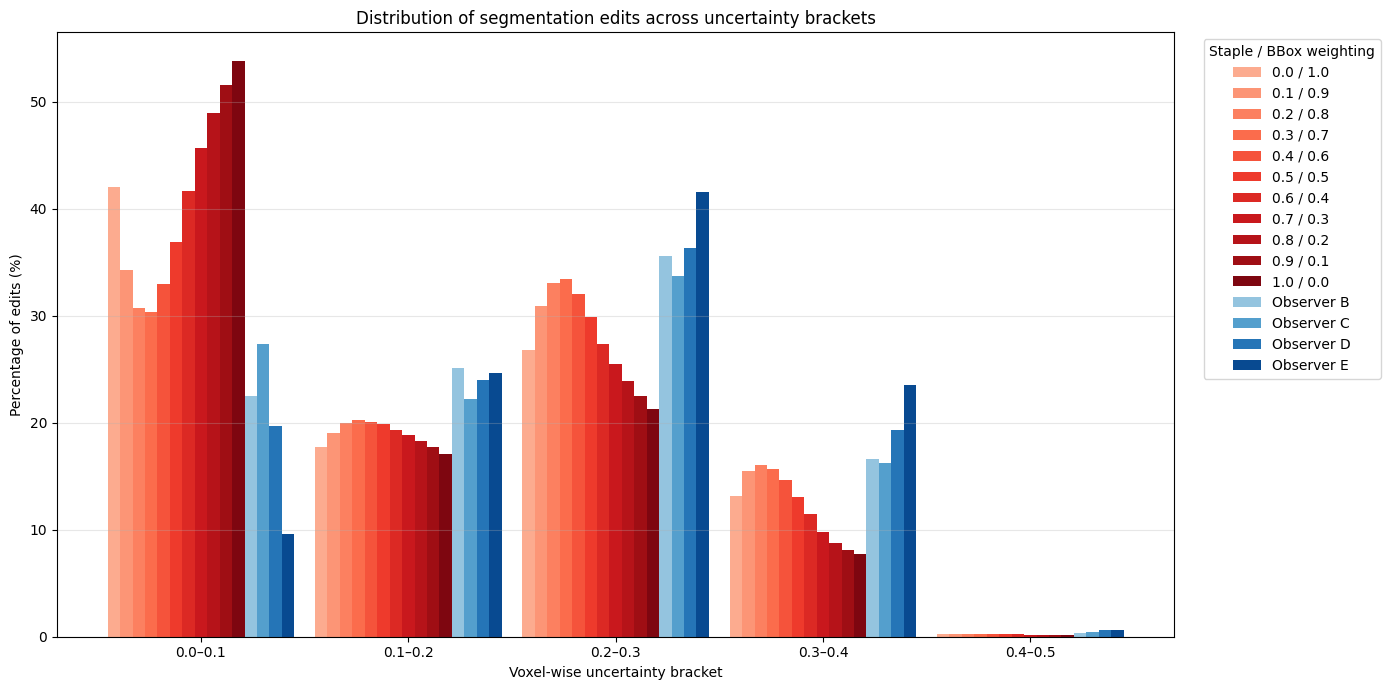

In [18]:
# ============================================================
# RUN
# ============================================================

weighting_lists = [
    (0.0, 1.0),
    (0.1, 0.9),
    (0.2, 0.8),
    (0.3, 0.7),
    (0.4, 0.6),
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1),
    (1.0, 0.0),
]

edit_counts, fig, ax = plot_all_weightings_edits_by_uncertainty(
    root=root,
    subjects=subjects,
    weighting_lists=weighting_lists,
    logits_folder="saved_logits_new",
    threshold=0.0,
    normalize=True,
    crop_margin=30,
)